In [3]:
import os
os.getcwd()

'c:\\Users\\aka90\\Desktop\\abhi vs code\\spyder code machine learning'

In [2]:
import numpy as np          
import pandas as pd    
import matplotlib.pyplot as plt
import seaborn as sns  
from sklearn.Preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

ModuleNotFoundError: No module named 'sklearn.Preprocessing'

In [4]:
pip install preprocessing

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [7]:
data = pd.read_csv(r"C:\Users\aka90\Downloads\classroom pdf\PYTHON NOTES\JULY\17 juny\15th, 16th, 17th - svr, dtr, rf,knn\HEIGHT & WEIGHT\SOCR-HeightWeight.csv")

In [8]:
data.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [9]:
#converting weight pounds to kg
data['Weight_kg']=data['Weight(Pounds)']*0.453592  

# Convert inches to the desired format (feet.inches) 
data['Height(Feet.Inches)'] = data['Height(Inches)'] // 12 + (data['Height(Inches)'] % 12) / 10

In [10]:
data

,Index,Height(Inches),Weight(Pounds),Weight_kg,Height(Feet.Inches)
0,1,65.78331,112.9925,51.252494,5.578331
1,2,71.51521,136.4873,61.909547,6.151521
2,3,69.39874,153.0269,69.411778,5.939874
3,4,68.21660,142.3354,64.562199,5.821660
4,5,67.78781,144.2971,65.452010,5.778781
...,...,...,...,...,...
24995,24996,69.50215,118.0312,53.538008,5.950215
24996,24997,64.54826,120.1932,54.518674,5.454826
24997,24998,64.69855,118.2655,53.644285,5.469855
24998,24999,67.52918,132.2682,59.995797,5.752918


In [11]:
data.describe()

,Index,Height(Inches),Weight(Pounds),Weight_kg,Height(Feet.Inches)
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,67.993114,127.079421,57.642209,5.795967
std,7217.022701,1.901679,11.660898,5.289290,0.183513
min,1.000000,60.278360,78.014760,35.386871,5.027836
25%,6250.750000,66.704397,119.308675,54.117461,5.670440
50%,12500.500000,67.995700,127.157750,57.677738,5.799570
75%,18750.250000,69.272958,134.892850,61.186318,5.927296
max,25000.000000,75.152800,170.924000,77.529759,6.315280


In [12]:
drop_columns = ['Index', 'Height(Inches)', 'Weight(Pounds)']
data = data.drop(columns=drop_columns, axis=1)

In [13]:
data

,Weight_kg,Height(Feet.Inches)
0,51.252494,5.578331
1,61.909547,6.151521
2,69.411778,5.939874
3,64.562199,5.821660
4,65.452010,5.778781
...,...,...
24995,53.538008,5.950215
24996,54.518674,5.454826
24997,53.644285,5.469855
24998,59.995797,5.752918


In [14]:
data.shape

(25000, 2)

In [15]:
data.sample(3)

,Weight_kg,Height(Feet.Inches)
11359,56.758330,5.851834
22780,62.315104,5.630784
2530,64.411788,6.074732


In [16]:
data.isnull()

,Weight_kg,Height(Feet.Inches)
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
24995,False,False
24996,False,False
24997,False,False
24998,False,False


In [17]:
data.isnull().sum()

Weight_kg              0
Height(Feet.Inches)    0
dtype: int64

In [18]:
data.isna().any()

Weight_kg              False
Height(Feet.Inches)    False
dtype: bool

In [19]:
data.dtypes

Weight_kg              float64
Height(Feet.Inches)    float64
dtype: object

In [20]:
data.corr()

,Weight_kg,Height(Feet.Inches)
Weight_kg,1.000000,0.499192
Height(Feet.Inches),0.499192,1.000000


In [21]:
data.describe()

,Weight_kg,Height(Feet.Inches)
count,25000.000000,25000.000000
mean,57.642209,5.795967
std,5.289290,0.183513
min,35.386871,5.027836
25%,54.117461,5.670440
50%,57.677738,5.799570
75%,61.186318,5.927296
max,77.529759,6.315280


<Axes: xlabel='Height(Feet.Inches)'>

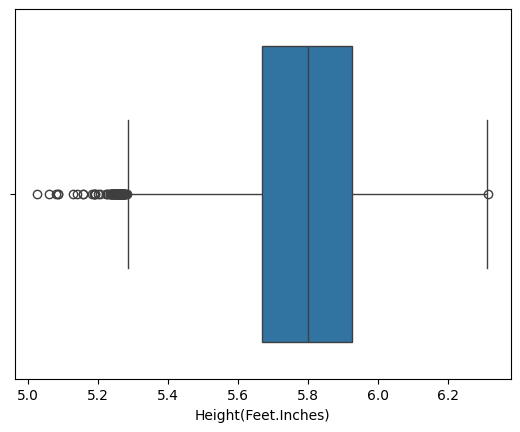

In [22]:
sns.boxplot(x=data['Height(Feet.Inches)'])

<Axes: xlabel='Weight_kg'>

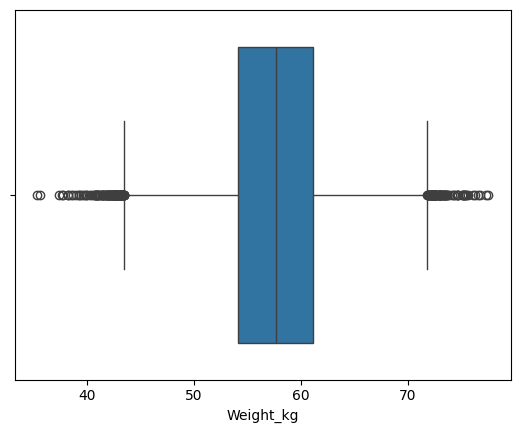

In [23]:
sns.boxplot(x=data["Weight_kg"])

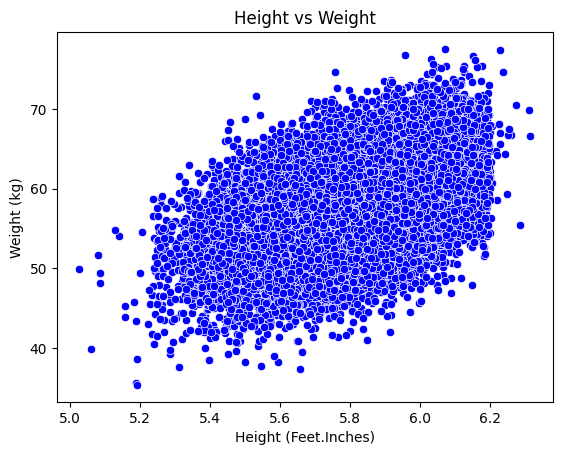

In [24]:
x = data[['Height(Feet.Inches)']]
y = data['Weight_kg']

sns.scatterplot(x=x['Height(Feet.Inches)'], y=y, color='blue')
plt.title('Height vs Weight')
plt.xlabel('Height (Feet.Inches)')  
plt.ylabel('Weight (kg)')
plt.show()

In [25]:
data.sample(3)

,Weight_kg,Height(Feet.Inches)
7824,56.246134,5.793137
5667,59.684361,5.402390
13901,59.605028,5.689899


In [26]:
x= data.iloc[:,1]
y= data.iloc[:,0]

In [27]:
x

0        5.578331
1        6.151521
2        5.939874
3        5.821660
4        5.778781
           ...   
24995    5.950215
24996    5.454826
24997    5.469855
24998    5.752918
24999    5.887761
Name: Height(Feet.Inches), Length: 25000, dtype: float64

In [28]:
data.columns[1]

'Height(Feet.Inches)'

In [29]:
data.columns[0]

'Weight_kg'

In [30]:
scaler_x = StandardScaler()
x_scaled = scaler_x.fit_transform(x.values.reshape(-1,1))


scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [31]:
# spliting data to 80% and 20% ratio

# spliting data to 80% and 20% ratio

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [33]:
print('Shape of trining data')
print(x_train.shape)
print(y_train.shape)

print('Shpae of testing data')
print(x_test.shape)
print(y_test.shape)

Shape of trining data
(20000,)
(20000,)
Shpae of testing data
(5000,)
(5000,)


In [34]:
#linear regression model X should be 2d array so we are reshaping it to 2d array

# Reshape training data
x_train_2d = x_train.values.reshape(-1, 1)
y_train_2d = y_train.values.reshape(-1, 1)

# Reshape testing data
x_test_2d = x_test.values.reshape(-1, 1)
y_test_2d = y_test.values.reshape(-1, 1)

print("Shape of training data (x):", x_train_2d.shape)
print("Shape of training data (y):", y_train_2d.shape)
print("Shape of testing data (x):", x_test_2d.shape)
print("Shape of testing data (y):", y_test_2d.shape)

Shape of training data (x): (20000, 1)
Shape of training data (y): (20000, 1)
Shape of testing data (x): (5000, 1)
Shape of testing data (y): (5000, 1)


In [35]:
lr=LinearRegression() #linear Regression
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
lr.fit(x_train_2d,y_train_2d)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
y_pred=lr.predict(x_test_2d)
y_pred[:10]

array([[55.94425481],
       [60.91226889],
       [56.56867714],
       [56.42643564],
       [51.52547113],
       [52.93798976],
       [60.30463034],
       [60.27256006],
       [62.74472434],
       [63.0616341 ]])

In [40]:
y_test_2d[:10]

array([[60.87349789],
       [64.25661383],
       [50.63170805],
       [53.62895327],
       [46.5397639 ],
       [48.20970821],
       [55.81821505],
       [55.03481631],
       [76.60307055],
       [55.98708736]])

In [41]:
mean_squared_error(y_pred,y_test_2d)

21.69730652290755

In [42]:
model_dtr=DecisionTreeRegressor()
model_dtr

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [44]:
model_dtr.fit(x_train_2d, y_train_2d)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [46]:
y_pred_dtr=model_dtr.predict(x_test_2d)
y_pred_dtr[:5]

array([63.37542065, 56.46639802, 56.7162365 , 64.71347169, 57.84078178])

In [47]:
mean_squared_error(y_pred_dtr,y_test_2d)

41.50751860513505

# Random Forest Regressor

model_rfr=RandomForestRegressor()
model_rfr.fit(x_train_2d,y_train_2d)

In [48]:
model_rfr=RandomForestRegressor()
model_rfr.fit(x_train_2d,y_train_2d)

C:\Users\aka90\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
y_pred_rfr=(x_test_2d)
y_pred_rfr[:10]

array([[5.675233],
       [6.023626],
       [5.719022],
       [5.709047],
       [5.365356],
       [5.464412],
       [5.981014],
       [5.978765],
       [6.152131],
       [6.174355]])

In [50]:
mean_squared_error(y_pred_rfr,y_test_2d)

2708.30376658499

## Hyperparameter turing

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

# Define hyperparameters to tune
param_grid = {
    'fit_intercept': [True, False],
    'copy_X': [True, False]
}

# Create a Linear Regression model
model_lr = LinearRegression()

# Initialize GridSearchCV
grid_search = GridSearchCV(model_lr, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model
grid_search.fit(x_train_2d, y_train_2d)

# Print the best parameters and best MSE score
print("Best Parameters:", grid_search.best_params_)
print("Best Negative MSE Score:", grid_search.best_score_)

Best Parameters: {'copy_X': True, 'fit_intercept': True}
Best Negative MSE Score: -20.836260216566206


In [52]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model
model_lr = LinearRegression()

# Perform 10-fold cross-validation
accuracy_scores = cross_val_score(model_lr, x_train_2d, y_train_2d, cv=10, scoring='neg_mean_squared_error')

# Convert negative mean squared error to positive
mse_scores = -accuracy_scores

# Print the MSE scores
print("MSE Scores:", mse_scores)

MSE Scores: [21.65411512 21.79844701 20.33072238 21.2128048  21.84713487 20.47547042
 20.38317103 20.4544885  21.45193422 18.76081422]


### Final model

In [53]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model with the best parameters
final_model = LinearRegression(fit_intercept=False, copy_X=True)

# Fit the model to the entire training data
final_model.fit(x_train_2d, y_train_2d)

# Now you can use final_model to make predictions on new data

,fit_intercept,False
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### converting to Pickle file

In [54]:
import pickle

# Define the filename for the pickle file
filename = 'final_model.pkl'

# Save the final_model to a pickle file
with open(filename, 'wb') as file:
    pickle.dump(final_model, file)


In [55]:
os.path.abspath('final_model.pkl')

'c:\\Users\\aka90\\Desktop\\abhi vs code\\spyder code machine learning\\final_model.pkl'

In [56]:
import pickle
import numpy as np

# Load the saved model from the file
filename = 'final_model.pkl'
with open(filename, 'rb') as file:
    loaded_model = pickle.load(file)

# Input height for prediction
height_input = 6.0

# Reshape the input height to match the shape expected by the model (2D array)
height_input_2d = np.array(height_input).reshape(1, -1)

# Use the loaded model to make predictions
predicted_weight = loaded_model.predict(height_input_2d)

# Print the predicted weight
print("Predicted weight:", predicted_weight[0, 0])

Predicted weight: 59.7202378537033
